$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
$$

## Setup

You are given the following data situation:

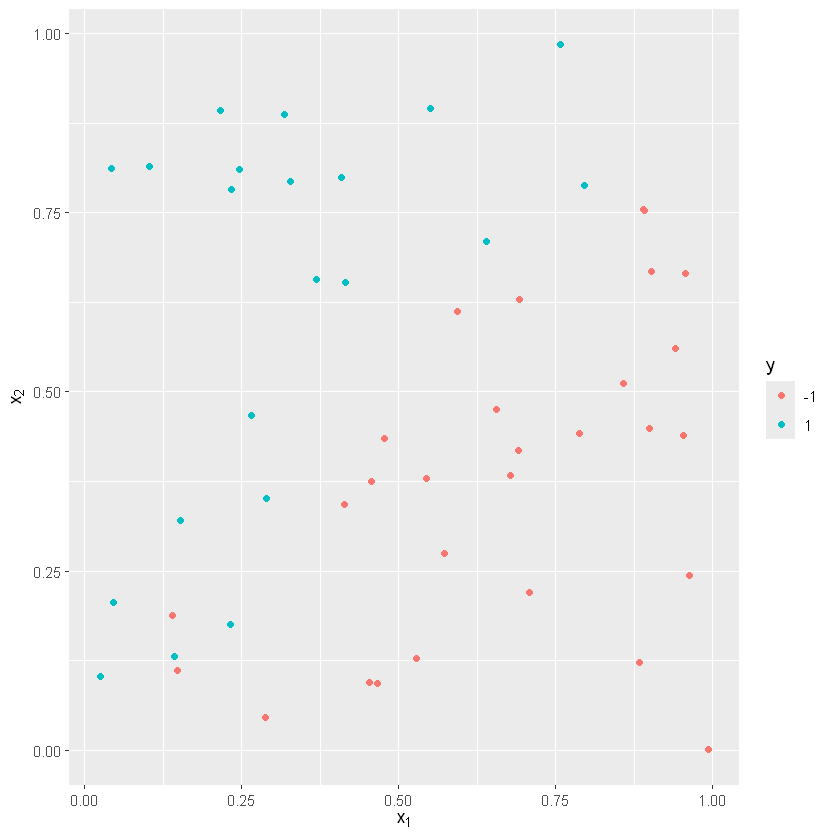

In [1]:
#| label: setup_data
library(ggplot2)

set.seed(123)

X <- matrix(runif(100), ncol = 2)
y <- -((X %*% c(-1, 1) + rnorm(50, 0, 0.1) < 0) * 2 - 1)
df <- as.data.frame(X)
df$type <- as.character(y)

ggplot(df) +
  geom_point(aes(x = V1, y = V2, color = type)) +
  xlab(expression(x[1])) +
  ylab(expression(x[2])) +
  labs(color = "y")

::: callout-note
**R vs. Python parity.** R's `set.seed(123)` and Python's `np.random.seed(123)` use *different* RNGs. The data above (and consequently the optima below) differ between languages. Both implementations are correct; only the underlying data differs. When comparing R and Python, look at *algorithmic behavior* (convergence, bracket shrinking, zig-zag pattern) rather than expecting numerically identical $\bm{\theta}$ values.
:::

In the following we want to estimate a linear SVM without intercept and with $\lambda = 1$. We assume we know that $\bm{\theta}_2 = 2$.

## (a) Convexity of a 1D slice

Show that if $f:\R^2 \to \R$ is convex then $g_c: \R \to \R, \ x \mapsto f(x, c)$ for any $c\in\R$ is convex.

**Solution.**

Since $f$ is convex, for arbitrary $\mathbf{x}, \mathbf{y} \in \R^2$ and $t \in [0,1]$:

$$f(\mathbf{x} + t(\mathbf{y} - \mathbf{x})) \leq f(\mathbf{x}) + t(f(\mathbf{y}) - f(\mathbf{x})).$$

Apply this to $\mathbf{x}_c = (x, c)^\top$ and $\mathbf{y}_c = (y, c)^\top$ with $x, y \in \R$ and fixed $c \in \R$. The right-hand sides equal $g_c(x)$ and $g_c(y)$, and the left-hand side equals $g_c(x + t(y-x))$, giving

$$g_c(x + t(y-x)) \leq g_c(x) + t(g_c(y) - g_c(x)).$$

Hence $g_c$ is convex.

**Geometric intuition.** Fixing one coordinate restricts $f$ to the affine line $\{(x, c) : x \in \R\}$. Convexity is preserved under any affine restriction.

**Why we care.** Every 1D solver in this exercise (golden-section, Brent's, alternating univariate minimization) only works on convex 1D functions. This proof is what licenses applying them to one parameter at a time of a *multivariate* convex SVM objective.

## (b) Why the non-geometric primal SVM

Explain why the non-geometric primal linear SVM formulation should be used rather than the geometric one if we want to find $\bm{\theta}_1$ via the golden-ratio algorithm.

*Note: We use this algorithm for educational purposes; in practice more advanced algorithms are typically used.*

**Solution.**

Recall the two equivalent SVM primal formulations (related by $C = \frac{1}{2\lambda}$):

**Geometric primal:**

$$\min_{\bm{\theta}, \theta_0, \bm{\zeta}} \quad \tfrac{1}{2}\|\bm{\theta}\|^2 + C \sum_{i=1}^n \zeta_i \quad \text{s.t.} \quad y^{(i)}(\bm{\theta}^\top\xv^{(i)} + \theta_0) \geq 1 - \zeta_i,\ \zeta_i \geq 0.$$

**Non-geometric primal:**

$$\min_{\bm{\theta}} \quad \lambda\|\bm{\theta}\|^2 + \sum_{i=1}^n \max\!\left(0,\ 1 - y^{(i)}\bm{\theta}^\top\xv^{(i)}\right).$$

Golden-section and Brent's method are *unconstrained* 1D solvers — they have no mechanism for the geometric primal's $2n$ inequality constraints, and restricting to one parameter (per (a)) does not remove them. The non-geometric primal is unconstrained and convex in $\bm{\theta}$; by (a) its restriction to $\bm{\theta}_1$ (with $\bm{\theta}_2$ fixed) stays convex, so a 1D solver applies directly.

## (c) Golden-section search

Find $\bm{\theta}_1$ via the golden-section algorithm. Implement the algorithm yourself. Use absolute error $0.01$ as termination criterion and $[-3, 3]$ as the starting interval.

In [2]:
#| label: solution_c_code
# SVM objective (no intercept, lambda = 1)
f <- function(theta) {
  theta %*% theta +
    sum(sapply(1 - y * (X %*% theta), function(x) max(x, 0)))
}

# Restrict to theta_1 with theta_2 fixed at 2
ft1 <- function(theta_1) f(c(theta_1, 2))

# phi = (sqrt(5) - 1) / 2 is the golden ratio reciprocal (~0.618).
# Picking the inner candidates at this fraction makes each iteration shrink
# the bracket by exactly (1-phi) ~= 0.382 AND lets us reuse one of the two
# previous evaluation points the next round - so only ONE new function call
# per iteration is needed.
phi <- (sqrt(5) - 1) / 2

gr <- function(f, lx = -3, rx = 3, abs_error = 0.01) {
  xbest_old <- Inf
  iters <- 0
  dist <- rx - lx
  cx <- c(lx + (1 - phi) * dist, rx - (1 - phi) * dist)

  while (TRUE) {
    iters <- iters + 1
    fcx1 <- f(cx[1])
    fcx2 <- f(cx[2])

    # Keep the side containing the better candidate; replace the discarded
    # candidate with its golden-section reflection so the SAME outer point
    # plus ONE new point cover the new (smaller) bracket.
    if (fcx1 < fcx2) {
      fbest <- fcx1; xbest <- cx[1]
      rx <- cx[2]
      cx[2] <- cx[2] - (cx[1] - lx)
    } else {
      fbest <- fcx2; xbest <- cx[2]
      lx <- cx[1]
      cx[1] <- cx[1] + (rx - cx[2])
    }
    cx <- sort(cx)

    if (abs(xbest_old - xbest) < abs_error) {
      return(list(xbest = xbest, fbest = fbest, iters = iters))
    }
    xbest_old <- xbest
  }
}

res_gr <- gr(ft1)
cat(sprintf("golden-section: theta_1* = %.4f, f = %.4f, iters = %d\n",
            res_gr$xbest, res_gr$fbest, res_gr$iters))

golden-section: theta_1* = -2.4590, f = 29.9129, iters = 5


## (d) Parabola interpolation through three points

Given three points $(x_1, y_1), (x_2, y_2), (x_3, y_3)$ show that the parameters $a, b, c \in \R$ of the interpolating parabola $p(x) = ax^2 + bx + c$ can be found via

$$
\begin{pmatrix}a \\ b \\ c \end{pmatrix} = \begin{pmatrix} x_1^2 & x_1 & 1 \\ x_2^2 & x_2 & 1 \\ x_3^2 & x_3 & 1 \end{pmatrix}^{-1} \begin{pmatrix}y_1 \\ y_2 \\ y_3 \end{pmatrix}.
$$

**Solution.**

Three equations:

$$ax_i^2 + b x_i + c = y_i \quad \text{for } i = 1, 2, 3.$$

Stacking them in matrix form gives $\bm{\Lambda} (a, b, c)^\top = (y_1, y_2, y_3)^\top$ with $\bm{\Lambda}$ as in the problem statement. $\bm{\Lambda}$ is the **Vandermonde matrix** of $(x_1, x_2, x_3)$; its determinant is $(x_2 - x_1)(x_3 - x_1)(x_3 - x_2)$, which is nonzero iff the three $x_i$ are pairwise distinct.

**Failure mode worth knowing.** In Brent's method (next part), if two of the bracket points coalesce, $\bm{\Lambda}$ becomes singular and parabolic interpolation breaks. Production Brent implementations guard against this by falling back to a golden-section step whenever the parabolic candidate is invalid.

## (e) Brent's method

Find $\bm{\theta}_1$ via Brent's method. Implement a simplified version (only check whether the proposed point is in the current interval) of the algorithm. Use absolute error $0.01$ as termination criterion and $[-3, 3]$ as the starting interval. For the first step, use a golden-ratio step.

**Brent's idea.** When the function looks parabolic near the minimum, fit a parabola through three candidate points $(lx, rx, cx)$ and jump to its vertex (one quadratic-interpolation step from (d)). When the parabola gives a bad point (vertex outside the current bracket, or matrix near-singular), fall back to a golden-section step. Result: near-quadratic convergence on smooth functions, golden's safety on rough ones.

In [3]:
#| label: solution_e_code
# One golden-section step (used as fallback inside brent).
gr_step <- function(f, lx, rx) {
  dist <- rx - lx
  cxs <- c(lx + (1 - phi) * dist, rx - (1 - phi) * dist)
  fcx <- sapply(cxs, f)
  if (fcx[1] < fcx[2]) {
    fbest <- fcx[1]; cx <- cxs[1]; rx <- cxs[2]
  } else {
    fbest <- fcx[2]; cx <- cxs[2]; lx <- cxs[1]
  }
  c(lx, rx, cx, fbest)
}

brent <- function(f, lx = -3, rx = 3, abs_error = 0.01) {
  xbest_old <- Inf
  iters <- 0; parabola_steps <- 0; golden_steps <- 0
  first_step <- TRUE
  cx <- NA_real_

  while (TRUE) {
    iters <- iters + 1

    if (first_step || cx <= lx || cx >= rx) {
      # First iteration OR previous candidate outside bracket: golden step
      res <- gr_step(f, lx, rx)
      lx <- res[1]; rx <- res[2]; cx <- res[3]; xbest <- cx; fbest <- res[4]
      golden_steps <- golden_steps + 1
      first_step <- FALSE
    } else {
      # Quadratic interpolation: parabola through (lx, rx, cx), jump to vertex
      xs <- c(lx, rx, cx)
      fxs <- sapply(xs, f)
      params <- solve(t(sapply(xs, function(x) c(x^2, x, 1))), fxs)
      cx_new <- -params[2] / (2 * params[1])

      if (cx_new < rx & cx_new > lx) {
        cxs <- sort(c(cx, cx_new))
        fcx <- sapply(cxs, f)
        if (fcx[1] < fcx[2]) {
          fbest <- fcx[1]; cx <- cxs[1]; rx <- cxs[2]
        } else {
          fbest <- fcx[2]; cx <- cxs[2]; lx <- cxs[1]
        }
        xbest <- cx
        parabola_steps <- parabola_steps + 1
      } else {
        # Parabola vertex outside bracket: golden fallback
        res <- gr_step(f, lx, rx)
        lx <- res[1]; rx <- res[2]; cx <- res[3]; xbest <- cx; fbest <- res[4]
        golden_steps <- golden_steps + 1
      }
    }

    if (abs(xbest - xbest_old) < abs_error) {
      return(list(xbest = xbest, fbest = fbest, iters = iters,
                  parabola_steps = parabola_steps, golden_steps = golden_steps))
    }
    xbest_old <- xbest
  }
}

res_br <- brent(ft1)
cat(sprintf(paste0(
  "Brent:          theta_1* = %.4f, f = %.4f, ",
  "iters = %d (parabola=%d, golden=%d)\n"),
            res_br$xbest, res_br$fbest, res_br$iters,
            res_br$parabola_steps, res_br$golden_steps))
cat(sprintf("golden-section: iters = %d  (from c)\n", res_gr$iters))

Brent:          theta_1* = -2.4095, f = 29.9033, iters = 5 (parabola=4, golden=1)


golden-section: iters = 5  (from c)


**Cost trade-off.** Golden-section does no linear algebra per step but takes more steps. Brent solves a $3\times 3$ system per parabolic step (~10 flops) and converges in fewer iterations. On smooth objectives the speedup is large; on the SVM hinge loss above (kink at every margin violation) the speedup is modest because parabolic fits are often poor. The iteration counts printed above make this trade-off concrete.

## (f) Alternating univariate minimization

Now assume we do not know $\bm{\theta}_2$. Initial guess is $\bm{\theta}_2 = 0$. Alternately minimize w.r.t. either $\bm{\theta}_1$ or $\bm{\theta}_2$ via the golden-section method (starting interval reset to $[-3, 3]$ each time) while holding the other parameter fixed. Switch to the other parameter when absolute error is smaller than $0.01$. Repeat this procedure $10$ times.

We record the running $(\theta_1, \theta_2)$ in a list named `trace` so we can plot the optimization path in (g).

In [4]:
#| label: solution_f_code
t1 <- 0; t2 <- 0
trace <- matrix(c(t1, t2), nrow = 1)

for (i in 0:9) {
  if (i %% 2 == 0) {
    res <- gr(function(t) f(c(t, t2)))
    t1 <- res$xbest
  } else {
    res <- gr(function(t) f(c(t1, t)))
    t2 <- res$xbest
  }
  trace <- rbind(trace, c(t1, t2))
  cat(sprintf("iter %2d: theta = (% .4f, % .4f), f = %.4f\n",
              i, t1, t2, f(c(t1, t2))))
}

iter  0: theta = (-1.5836,  0.0000), f = 37.8786
iter  1: theta = (-1.5836,  1.5836), f = 32.4903
iter  2: theta = (-2.1246,  1.5836), f = 29.7429
iter  3: theta = (-2.1246,  1.5836), f = 29.7429
iter  4: theta = (-2.1246,  1.5836), f = 29.7429
iter  5: theta = (-2.1246,  1.5836), f = 29.7429
iter  6: theta = (-2.1246,  1.5836), f = 29.7429
iter  7: theta = (-2.1246,  1.5836), f = 29.7429
iter  8: theta = (-2.1246,  1.5836), f = 29.7429
iter  9: theta = (-2.1246,  1.5836), f = 29.7429


## (g) Optimization trace

How does the optimization trace of (f) look in parameter space?

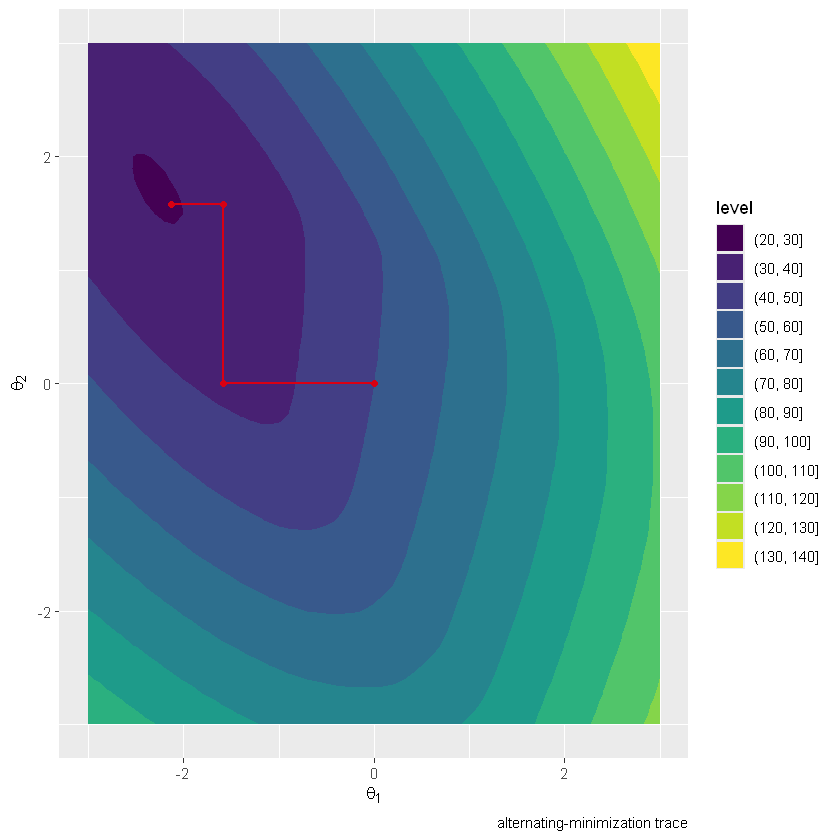

In [5]:
#| label: solution_g_code
x <- seq(-3, 3, by = 0.1)
xx <- expand.grid(X1 = x, X2 = x)
fxx <- apply(xx, 1, f)
df_plot <- data.frame(xx = xx, fxx = fxx)
trace_df <- as.data.frame(trace)
colnames(trace_df) <- c("V1", "V2")

ggplot() +
  geom_contour_filled(data = df_plot, aes(x = xx.X1, y = xx.X2, z = fxx)) +
  geom_path(data = trace_df, aes(x = V1, y = V2),
            color = "#D90012", linewidth = 0.6) +
  geom_point(data = trace_df, aes(x = V1, y = V2),
             color = "#D90012", size = 1.5) +
  xlab(expression(theta[1])) +
  ylab(expression(theta[2])) +
  labs(caption = "alternating-minimization trace")

The trace is an axis-aligned zig-zag. Each segment is parallel to one coordinate axis because the alternating procedure updates one parameter at a time, with the other held fixed. It **converges well before the 10 iterations finish**: once the updates stop reducing the loss, the remaining iterates land on the same point and stack on top of each other, so the path shows only a handful of visible segments rather than ten.

**Why this matters.** This problem is well-conditioned, so coordinate-wise descent converges quickly; the slowness shows on *poorly-conditioned* problems (elongated, rotated objective contours), where each axis-aligned step makes only tiny progress along the long axis of the level sets. That is why optimizing one coordinate at a time is rarely competitive in higher dimensions, and it motivates the *gradient-based* methods of the next chapter, which move along the steepest-descent direction instead of along the coordinate axes.